# Model Training & Evaluation

Notebook para entrenar y evaluar modelos de clasificación para la predicción de Churn.

**Modelos:** Logistic Regression, Random Forest, XGBoost, Gradient Boosting

**Métricas:** Recall, F1-Macro, AUC-ROC

**Validación:** Stratified K-Fold (5 folds)

**Optimización:** GridSearchCV

**Tracking:** MLflow

## 1. Configuración e Imports

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
import mlflow
import mlflow.sklearn
import joblib
import xgboost
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("✓ Imports completados")

/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


✓ Imports completados


In [ ]:
from pathlib import Path
import mlflow

repo = Path("/Users/nataliabernalgutierrez/Churn-Prediction").resolve()
mlruns_dir = repo / "mlruns"
mlruns_dir.mkdir(exist_ok=True)

mlflow.set_tracking_uri(f"file://{mlruns_dir}")
print("Tracking URI:", mlflow.get_tracking_uri())

exp = mlflow.set_experiment("churn_prediction")
print("Experiment:", exp.name, exp.experiment_id)


Tracking URI: file:///Users/nataliabernalgutierrez/Churn-Prediction/mlruns
Experiment: churn_prediction 131122253193653250


In [2]:
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
db_path = os.path.join(project_root, "mlflow.db")

mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("churn_prediction")
print(f"✓ MLflow configurado con SQLite: {db_path}")

2026/09/16 23:41:26 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/09/16 23:41:26 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


✓ MLflow configurado con SQLite: /Users/nataliabernalgutierrez/Churn-Prediction/mlflow.db


## 2. Carga de Datos

In [3]:
test_folder = '../data/resampled/original'
X_test = pd.read_csv(f'{test_folder}/X_test.csv')
y_test = pd.read_csv(f'{test_folder}/y_test.csv')['Churn']

print(f"Test set: {X_test.shape[0]} muestras, {X_test.shape[1]} features")
print(f"Distribución test:\n{y_test.value_counts()}")

Test set: 1407 muestras, 30 features
Distribución test:
Churn
0    1033
1     374
Name: count, dtype: int64


In [4]:
resampled_dir = '../data/resampled'
datasets = {}

for folder in sorted(os.listdir(resampled_dir)):
    if folder == 'original':
        continue
    path = os.path.join(resampled_dir, folder)
    if os.path.isdir(path) and 'X_train.csv' in os.listdir(path):
        X = pd.read_csv(f'{path}/X_train.csv')
        y = pd.read_csv(f'{path}/y_train.csv')['Churn']
        datasets[folder] = (X, y)
        print(f"✓ {folder}: {X.shape[0]} muestras, {X.shape[1]} features")

print(f"\nDatasets cargados: {list(datasets.keys())}")

✓ adasyn: 8292 muestras, 30 features
✓ random_over: 8260 muestras, 30 features
✓ random_under: 2990 muestras, 30 features
✓ smote: 8260 muestras, 30 features
✓ smote_enn: 4596 muestras, 30 features
✓ smote_tomek: 7506 muestras, 30 features

Datasets cargados: ['adasyn', 'random_over', 'random_under', 'smote', 'smote_enn', 'smote_tomek']


## 3. Definición de Modelos y Hiperparámetros

In [5]:
from sklearn.naive_bayes import GaussianNB

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'NaiveBayes': GaussianNB(),
    'XGBoost': xgboost.XGBClassifier(random_state=42, eval_metric='logloss'),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

print(f"Modelos definidos: {list(models.keys())}")

Modelos definidos: ['LogisticRegression', 'RandomForest', 'NaiveBayes', 'XGBoost', 'GradientBoosting']


In [6]:
param_grids = {
    'LogisticRegression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10]
    },
    'NaiveBayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    },
    'GradientBoosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    }
}

print("Hiperparámetros definidos para cada modelo")

Hiperparámetros definidos para cada modelo


## 4. Entrenamiento con GridSearchCV + MLflow

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

total = len(datasets) * len(models)
current = 0

for dataset_name, (X_train, y_train) in datasets.items():
    for model_name, model in models.items():
        current += 1
        print(f"\n{'='*60}")
        print(f"[{current}/{total}] Dataset: {dataset_name} | Modelo: {model_name}")
        print(f"{'='*60}")

        with mlflow.start_run(run_name=f"{dataset_name}_{model_name}"):
            mlflow.log_param("dataset", dataset_name)
            mlflow.log_param("model", model_name)
            mlflow.log_param("train_samples", X_train.shape[0])
            mlflow.log_param("features", X_train.shape[1])

            grid_search = GridSearchCV(
                model,
                param_grids[model_name],
                cv=cv,
                scoring='f1_macro',
                n_jobs=-1,
                verbose=0
            )
            grid_search.fit(X_train, y_train)

            mlflow.log_params(grid_search.best_params_)

            best_model = grid_search.best_estimator_
            y_pred = best_model.predict(X_test)
            y_proba = best_model.predict_proba(X_test)[:, 1]

            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro')
            auc_roc = roc_auc_score(y_test, y_proba)

            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1_macro", f1)
            mlflow.log_metric("auc_roc", auc_roc)
            mlflow.log_metric("best_cv_score", grid_search.best_score_)

            artifact_name = f"{dataset_name}_{model_name}".replace(" ", "_")
            mlflow.sklearn.log_model(best_model, artifact_path=artifact_name)

            results.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'Recall': recall,
                'F1-Macro': f1,
                'AUC-ROC': auc_roc,
                'Best_CV_F1_Macro': grid_search.best_score_,
                'Best_Params': str(grid_search.best_params_)
            })

            print(f"  ✓ Recall: {recall:.4f} | F1-Macro: {f1:.4f} | AUC-ROC: {auc_roc:.4f}")
            print(f"  ✓ Best CV F1-Macro: {grid_search.best_score_:.4f}")

print(f"\n{'='*60}")
print(f"✓ Entrenamiento completado: {len(results)} experimentos")
print(f"{'='*60}")


[1/30] Dataset: adasyn | Modelo: LogisticRegression


/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarni

  ✓ Recall: 0.6684 | F1-Macro: 0.7207 | AUC-ROC: 0.8191
  ✓ Best CV F1-Macro: 0.8259

[2/30] Dataset: adasyn | Modelo: RandomForest


2026/09/16 23:42:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/16 23:42:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  ✓ Recall: 0.6417 | F1-Macro: 0.7159 | AUC-ROC: 0.8087
  ✓ Best CV F1-Macro: 0.8402

[3/30] Dataset: adasyn | Modelo: NaiveBayes


...

  ✓ Recall: 0.7914 | F1-Macro: 0.6797 | AUC-ROC: 0.8027
  ✓ Best CV F1-Macro: 0.8070

[29/30] Dataset: smote_tomek | Modelo: XGBoost


2026/09/16 23:48:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/16 23:48:15 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  ✓ Recall: 0.6230 | F1-Macro: 0.7149 | AUC-ROC: 0.8197
  ✓ Best CV F1-Macro: 0.8637

[30/30] Dataset: smote_tomek | Modelo: GradientBoosting


2026/09/16 23:49:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/16 23:49:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  ✓ Recall: 0.5615 | F1-Macro: 0.6852 | AUC-ROC: 0.8017
  ✓ Best CV F1-Macro: 0.8647

✓ Entrenamiento completado: 30 experimentos


## 5. Evaluación en Test Set

In [8]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Macro', ascending=False)

print("\n📊 Resultados ordenados por F1-Macro:")
print(results_df[['Dataset', 'Model', 'Recall', 'F1-Macro', 'AUC-ROC']].to_string(index=False))


📊 Resultados ordenados por F1-Macro:
     Dataset              Model   Recall  F1-Macro  AUC-ROC
   smote_enn   GradientBoosting 0.732620  0.728162 0.818501
       smote LogisticRegression 0.663102  0.727163 0.825610
 random_over       RandomForest 0.601604  0.722603 0.815617
 smote_tomek LogisticRegression 0.657754  0.721711 0.828176
   smote_enn       RandomForest 0.735294  0.721284 0.823784
       smote       RandomForest 0.631016  0.720841 0.819583
      adasyn LogisticRegression 0.668449  0.720671 0.819064
       smote            XGBoost 0.633690  0.718618 0.819977
   smote_enn            XGBoost 0.716578  0.716261 0.824909
      adasyn       RandomForest 0.641711  0.715933 0.808734
 smote_tomek            XGBoost 0.622995  0.714897 0.819670
   smote_enn LogisticRegression 0.729947  0.714744 0.831575
 smote_tomek       RandomForest 0.625668  0.713359 0.817119
random_under       RandomForest 0.810160  0.711088 0.833598
random_under            XGBoost 0.810160  0.707865 0.836070
ra

In [9]:
best = results_df.iloc[0]
print(f"\n🏆 Mejor modelo: {best['Model']} con dataset {best['Dataset']}")
print(f"   Recall:    {best['Recall']:.4f}")
print(f"   F1-Macro:  {best['F1-Macro']:.4f}")
print(f"   AUC-ROC:   {best['AUC-ROC']:.4f}")


🏆 Mejor modelo: GradientBoosting con dataset smote_enn
   Recall:    0.7326
   F1-Macro:  0.7282
   AUC-ROC:   0.8185


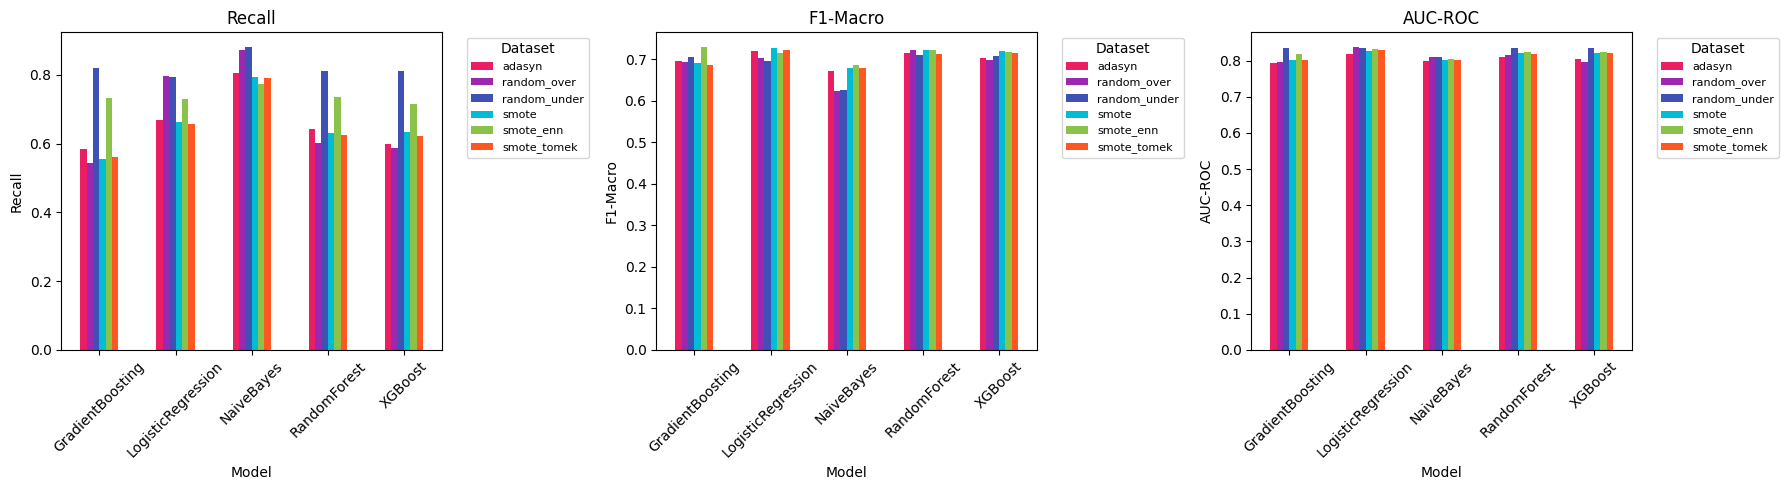

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Recall', 'F1-Macro', 'AUC-ROC']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for idx, metric in enumerate(metrics):
    pivot = results_df.pivot_table(index='Model', columns='Dataset', values=metric)
    pivot.plot(kind='bar', ax=axes[idx], color=['#E91E63', '#9C27B0', '#3F51B5', '#00BCD4', '#8BC34A', '#FF5722'])
    axes[idx].set_title(metric)
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Optimización de Threshold

In [11]:
best_model_name = best['Model']
best_dataset_name = best['Dataset']
best_params_str = best['Best_Params']

import ast
best_params = ast.literal_eval(best_params_str)

X_train_best, y_train_best = datasets[best_dataset_name]

final_model = models[best_model_name].set_params(**best_params)
final_model.fit(X_train_best, y_train_best)

y_proba = final_model.predict_proba(X_test)[:, 1]

print(f"Modelo final: {best_model_name} (Dataset: {best_dataset_name})")
print(f"Parámetros: {best_params}")

Modelo final: GradientBoosting (Dataset: smote_enn)
Parámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


In [12]:
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    threshold_results.append({
        'Threshold': round(t, 2),
        'Recall': recall_score(y_test, y_pred_t),
        'F1-Macro': f1_score(y_test, y_pred_t, average='macro'),
        'Predictions_Pos': y_pred_t.sum()
    })

threshold_df = pd.DataFrame(threshold_results)
print("\n📊 Métricas por Threshold:")
print(threshold_df.to_string(index=False))


📊 Métricas por Threshold:
 Threshold   Recall  F1-Macro  Predictions_Pos
      0.10 0.780749  0.705974              581
      0.15 0.770053  0.713138              560
      0.20 0.759358  0.713827              549
      0.25 0.756684  0.718699              539
      0.30 0.751337  0.723271              527
      0.35 0.743316  0.722287              521
      0.40 0.743316  0.726874              514
      0.45 0.740642  0.727199              511
      0.50 0.732620  0.728162              502
      0.55 0.729947  0.729799              497
      0.60 0.721925  0.730746              488
      0.65 0.708556  0.725672              483
      0.70 0.697861  0.724874              474
      0.75 0.695187  0.724503              472
      0.80 0.684492  0.722999              464
      0.85 0.673797  0.720798              457


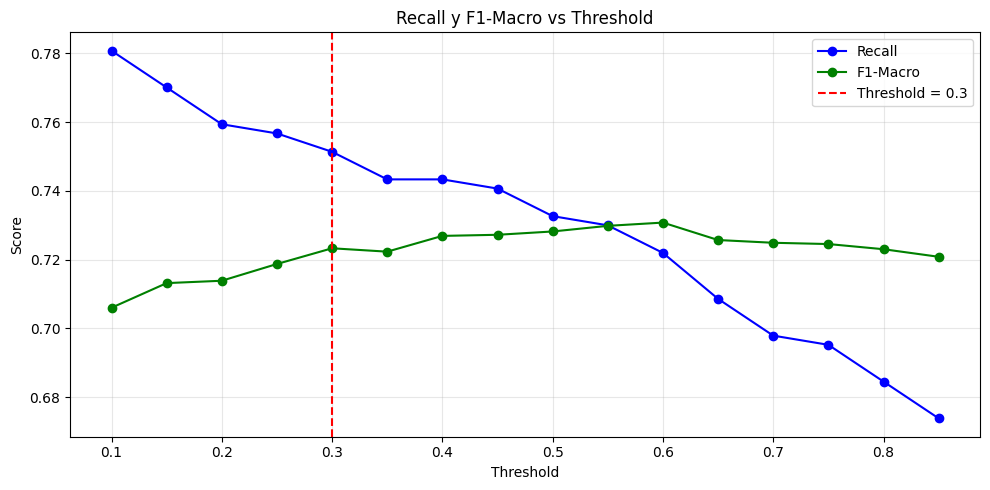

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(threshold_df['Threshold'], threshold_df['Recall'], 'b-o', label='Recall')
ax1.plot(threshold_df['Threshold'], threshold_df['F1-Macro'], 'g-o', label='F1-Macro')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.axvline(x=0.3, color='r', linestyle='--', label='Threshold = 0.3')
ax1.legend(loc='upper right')
ax1.set_title('Recall y F1-Macro vs Threshold')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
THRESHOLD = 0.3
y_pred_final = (y_proba >= THRESHOLD).astype(int)

print(f"\n📊 Resultados con Threshold = {THRESHOLD}")
print(f"{'='*40}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Macro:  {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_final))
print(f"\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_final, digits=4))


📊 Resultados con Threshold = 0.3
Recall:    0.7513
F1-Macro:  0.7233
AUC-ROC:   0.8185

Matriz de Confusión:
[[787 246]
 [ 93 281]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0     0.8943    0.7619    0.8228      1033
           1     0.5332    0.7513    0.6238       374

    accuracy                         0.7591      1407
   macro avg     0.7138    0.7566    0.7233      1407
weighted avg     0.7983    0.7591    0.7699      1407



## 7. Guardar Resultados

In [15]:
os.makedirs('../data/results', exist_ok=True)

results_df.to_csv('../data/results/model_training_results.csv', index=False)
print("✓ Resultados guardados en model_training_results.csv")

✓ Resultados guardados en model_training_results.csv


In [16]:
joblib.dump(final_model, f'../data/results/best_model_{best_model_name}.joblib')
print(f"✓ Mejor modelo guardado: best_model_{best_model_name}.joblib")

✓ Mejor modelo guardado: best_model_GradientBoosting.joblib


In [17]:
print(f"\n{'='*60}")
print(f"✓ PIPELINE COMPLETADO")
print(f"{'='*60}")
print(f"\nArchivos generados:")
print(f"  - ../data/results/model_training_results.csv")
print(f"  - ../data/results/best_model_{best_model_name}.joblib")
print(f"  - mlruns/ (MLflow experiments)")
print(f"\nPara ver MLflow UI ejecuta:")
print(f"  mlflow ui")


✓ PIPELINE COMPLETADO

Archivos generados:
  - ../data/results/model_training_results.csv
  - ../data/results/best_model_GradientBoosting.joblib
  - mlruns/ (MLflow experiments)

Para ver MLflow UI ejecuta:
  mlflow ui
